In [1]:
import numpy as np
import fmm2dpy as fmm
import matplotlib.pyplot as plt
import scienceplots  # noqa
import warnings

from hypermagnetics import plots
from hypermagnetics.sources import configure
from hypermagnetics.mt_eval import field_mt

warnings.filterwarnings('ignore')
plt.style.use(["science", "ieee"])


Minimum size: 0.015625


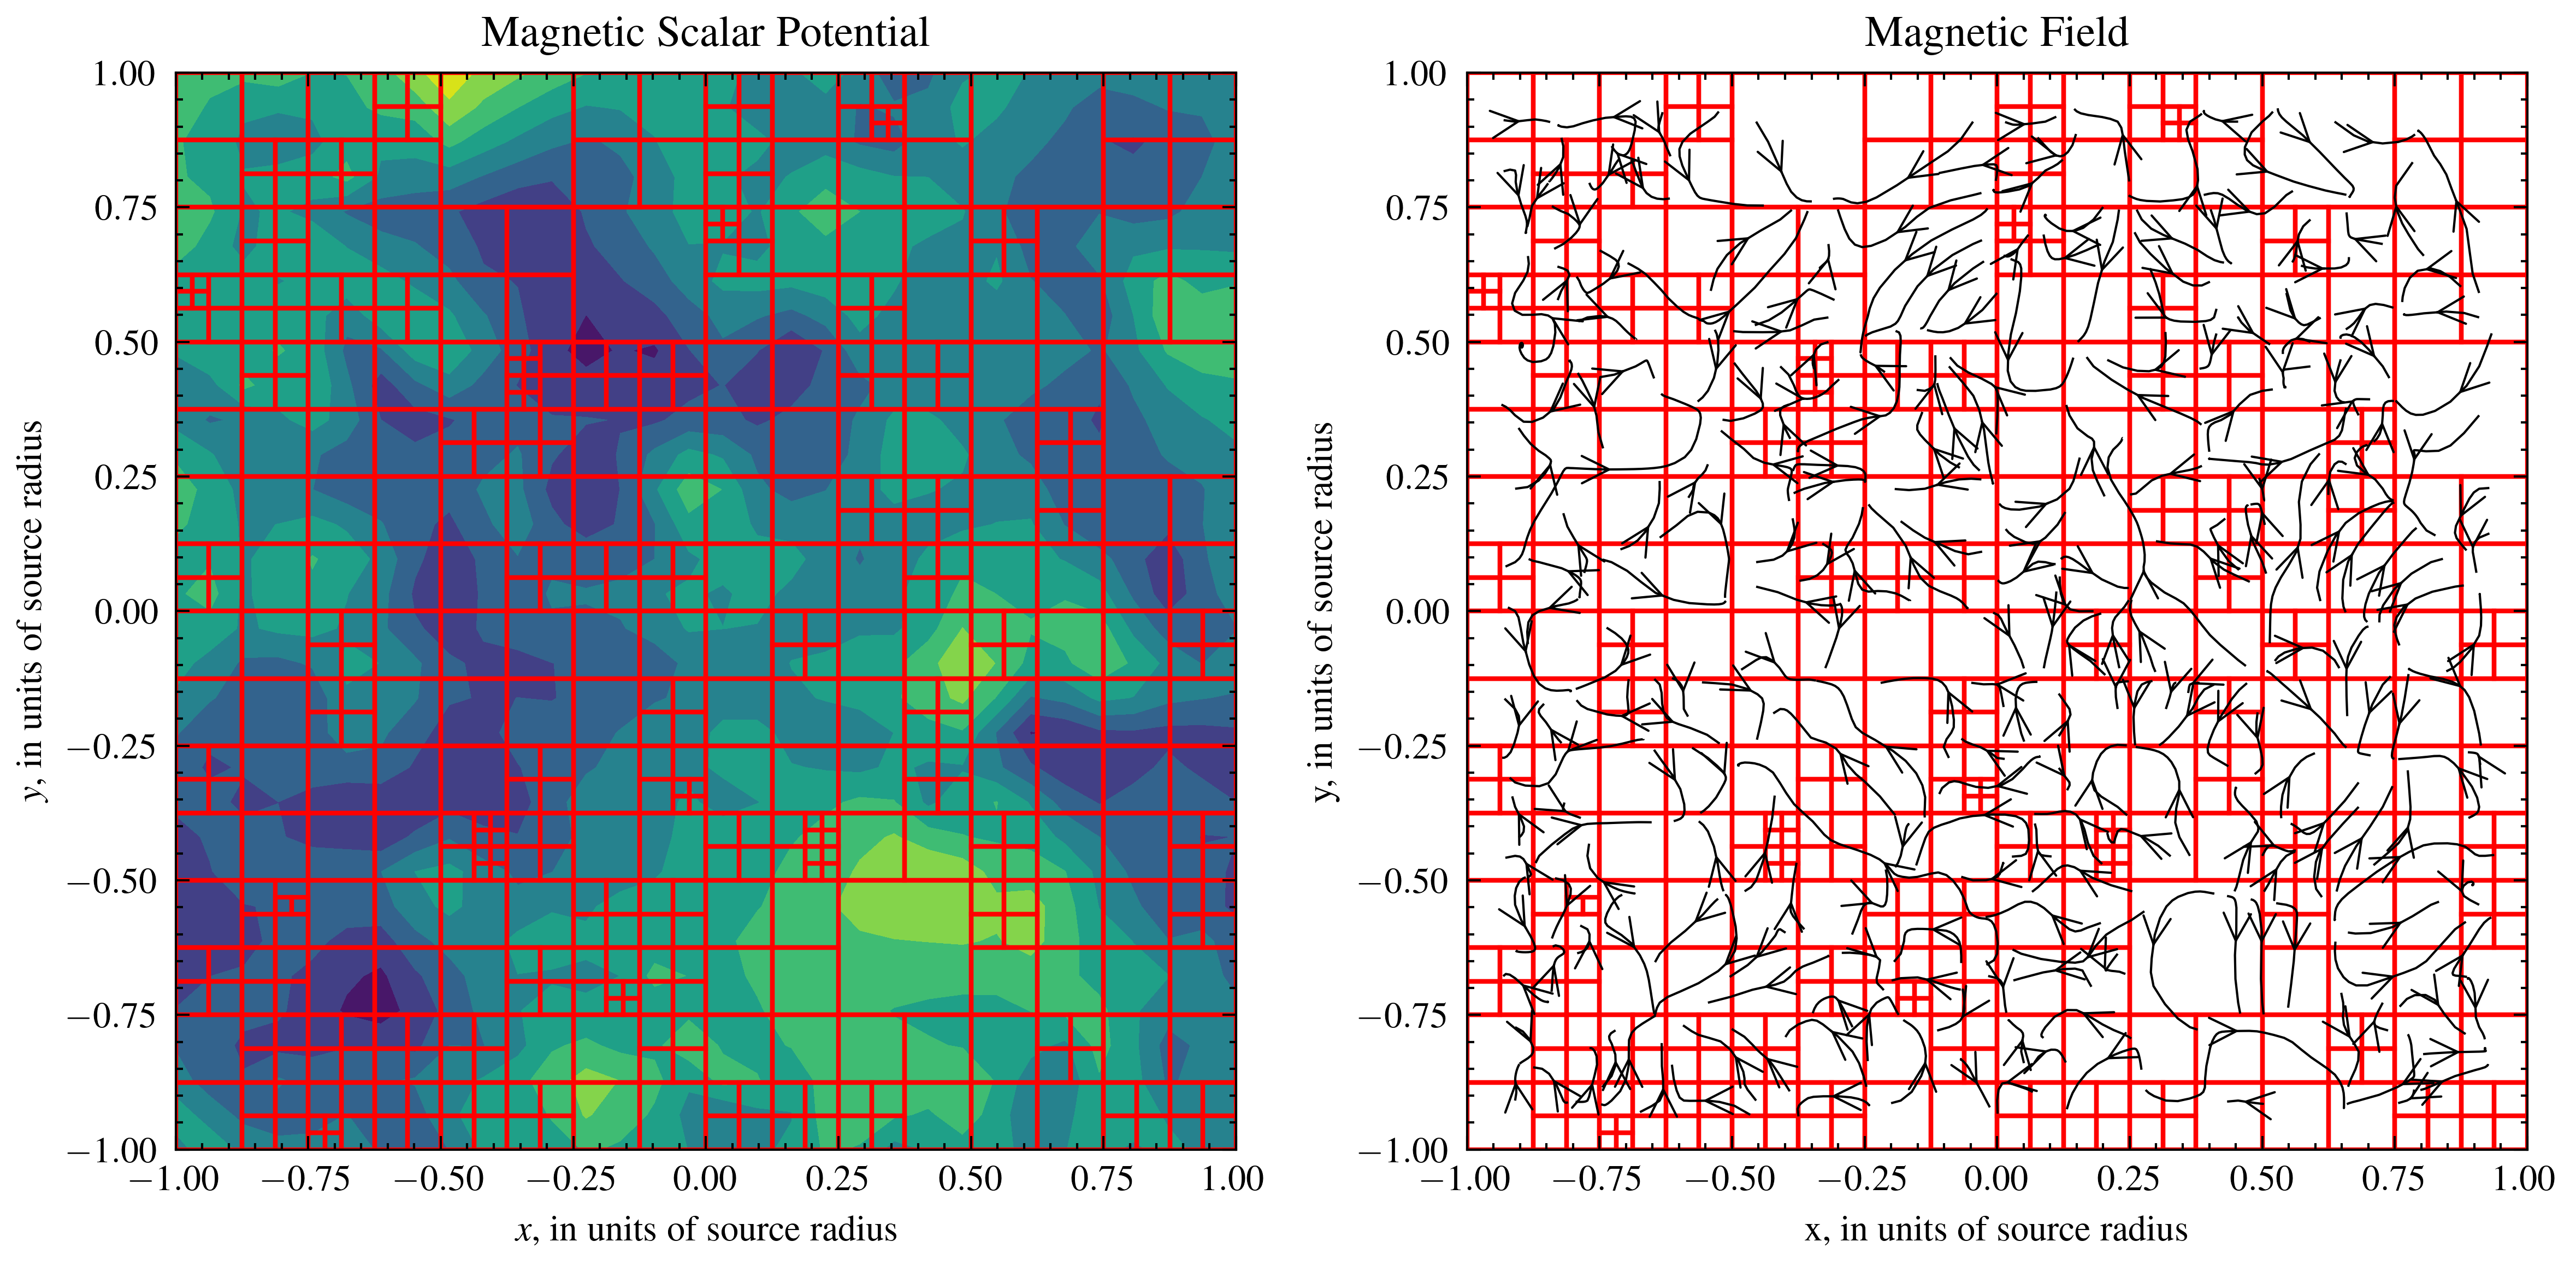

In [4]:
cfg = {
    "shape": "prism",
    "n_samples": 1,
    "lim": 1,
    "res": 32,
    "quadtree": True
}
train = configure(**cfg, n_sources=500, seed=0)
print("Minimum size:", train['sources'][..., 6:].min())

# Test the fixed plotting function
plots(train, loc=False, edge=True)

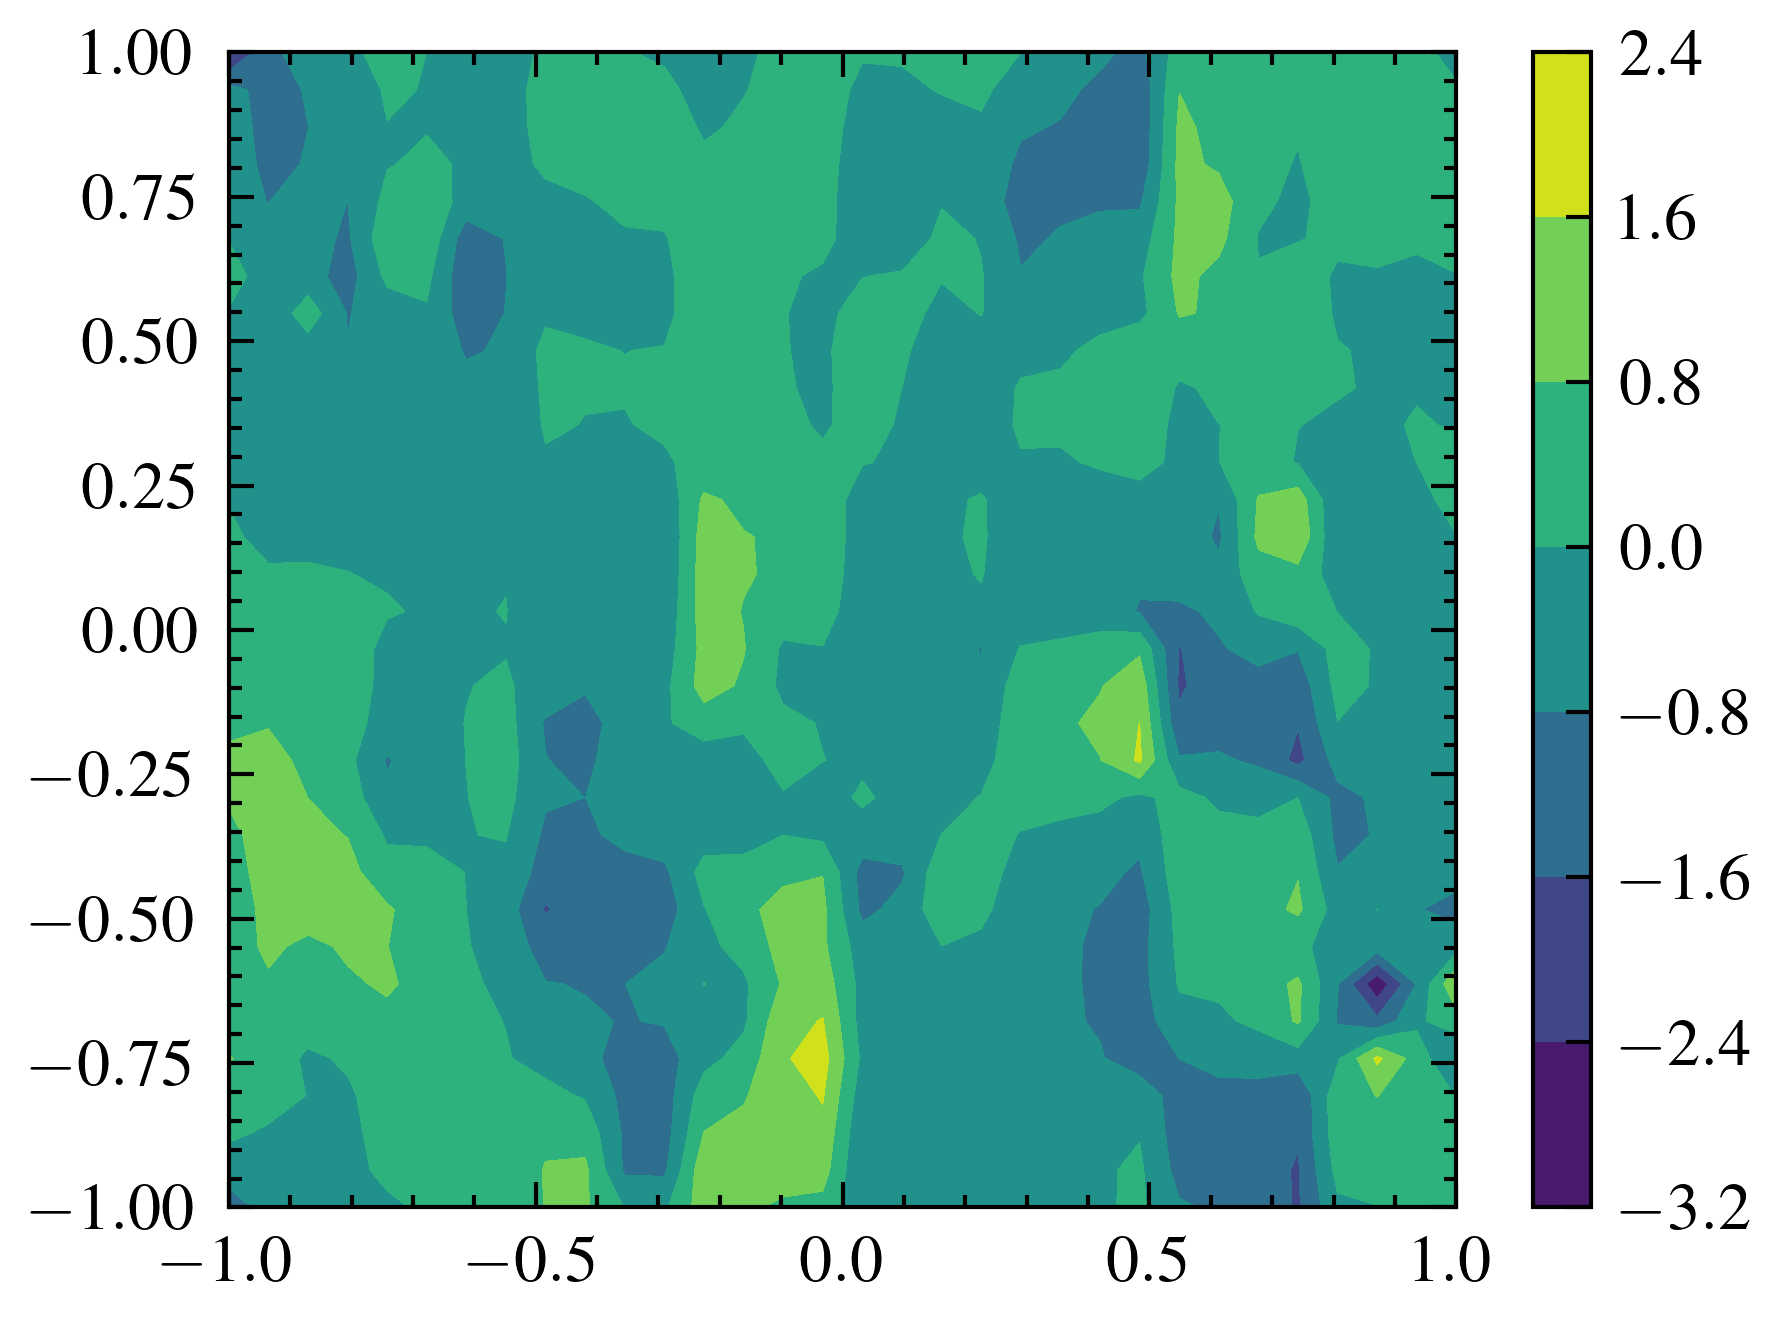

In [3]:
mt_sim, _ = field_mt(train['sources'], train['grid'], "prism")

x_grid = np.array(train['grid'][:, 0].reshape((cfg["res"], cfg["res"])))
y_grid = np.array(train['grid'][:, 1].reshape((cfg["res"], cfg["res"])))
mt_field = mt_sim[0, ..., :2].reshape((cfg["res"], cfg["res"], 2))
plt.contourf(x_grid, y_grid, mt_field[..., 0])
plt.colorbar()